## Section 0: Overview and Usage

This notebook implements three gate-by-gate simulations for the same validated JSON gate list:

- **Case A**: instantaneous ideal gates.
- **Case B**: pulse-level QuTiP dynamics with no dissipation.
- **Case C**: pulse-level QuTiP dynamics with dissipation from `T1`, `T2`, and optional cavity loss.

Usage:

1. Edit the configuration in **Section 2**.
2. Run the notebook top-to-bottom.
3. Compare Bloch trajectories, Wigner snapshots, and weakness metrics across A/B/C.

Pulse mapping used in this notebook:

- `Displacement` -> square cavity drive.
- `Rotation` -> Gaussian qubit drive.
- `SQR` -> simplified multitone Gaussian qubit drive using `cqed_sim` dispersive manifold frequencies.


## Section 1: Imports and Environment Checks


In [1]:
from __future__ import annotations

import copy
import importlib
import importlib.metadata
import json
import math
from pathlib import Path

REQUIRED_HINTS = {
    "numpy": "pip install numpy",
    "matplotlib": "pip install matplotlib",
    "qutip": "pip install qutip",
    "cqed_sim": "pip install -e .",
}
OPTIONAL_MODULES = ["ipywidgets"]

missing = []
versions = {}
for module_name, hint in REQUIRED_HINTS.items():
    try:
        module = importlib.import_module(module_name)
        versions[module_name] = getattr(module, "__version__", "unknown")
    except ModuleNotFoundError as exc:
        missing.append((module_name, hint, exc))

if missing:
    lines = ["Missing required notebook dependencies:"]
    for module_name, hint, exc in missing:
        lines.append(f"  - {module_name}: {exc}. Minimal install hint: {hint}")
    raise ModuleNotFoundError("\n".join(lines))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

import cqed_sim
from cqed_sim.core.frame import FrameSpec
from cqed_sim.core.ideal_gates import displacement_op, embed_cavity_op, embed_qubit_op, qubit_rotation_xy, sqr_op
from cqed_sim.core.model import DispersiveTransmonCavityModel
from cqed_sim.pulses.envelopes import gaussian_envelope, square_envelope
from cqed_sim.pulses.pulse import Pulse
from cqed_sim.sequence.scheduler import SequenceCompiler
from cqed_sim.sim.extractors import bloch_xyz_from_joint, cavity_moments, cavity_wigner, reduced_cavity_state, reduced_qubit_state
from cqed_sim.sim.noise import NoiseSpec
from cqed_sim.sim.runner import SimulationConfig, simulate_sequence
from cqed_sim.snap_opt.model import manifold_transition_frequency

def package_version(dist_name: str, default: str = "editable/local") -> str:
    try:
        return importlib.metadata.version(dist_name)
    except importlib.metadata.PackageNotFoundError:
        return default

optional_versions = {}
for module_name in OPTIONAL_MODULES:
    try:
        module = importlib.import_module(module_name)
        optional_versions[module_name] = getattr(module, "__version__", "available")
    except ModuleNotFoundError:
        optional_versions[module_name] = "not installed"

np.set_printoptions(precision=4, suppress=True)
print("Required versions:")
print(f"  numpy     : {versions['numpy']}")
print(f"  matplotlib: {versions['matplotlib']}")
print(f"  qutip     : {versions['qutip']}")
print(f"  cqed_sim  : {package_version('cqed-sim')}")
print("Optional:")
for name, version in optional_versions.items():
    print(f"  {name:<10}: {version}")


Required versions:
  numpy     : 1.26.4
  matplotlib: 3.10.0
  qutip     : 5.1.1
  cqed_sim  : 0.1.0
Optional:
  ipywidgets: 8.1.5


## Section 2: User Configuration


In [2]:
CONFIG = {
    "json_path": r"C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases.josn",
    "cavity_fock_cutoff": 24,
    "initial_qubit": "g",
    "initial_cavity_kind": "fock",
    "initial_cavity_fock": 0,
    "initial_cavity_alpha": {"re": 0.0, "im": 0.0},
    "initial_cavity_amplitudes": None,
    "wigner_every_gate": True,
    "wigner_stride": 1,
    "wigner_points": 81,
    "wigner_extent": 4.0,
    "wigner_max_cols": 5,
    "top_axis_label_stride": 1,
    "summary_max_rows": 20,
    "phase_track_max_n": 3,
    "phase_reference_threshold": 1.0e-8,
    "phase_unwrap": False,
    "dt_s": 1.0e-9,
    "max_step_s": 1.0e-9,
    "duration_displacement_s": 48.0e-9,
    "duration_rotation_s": 16.0e-9,
    "duration_sqr_s": 1.0e-6,
    "rotation_sigma_fraction": 1/6,
    "sqr_sigma_fraction": 1/6,
    "sqr_theta_cutoff": 1.0e-10,
    "use_rotating_frame": True,
    "omega_c_hz": 0.0,
    "omega_q_hz": 0.0,
    "qubit_alpha_hz": 0.0,
    "st_chi_hz": -2840421.354241756,
    "st_chi2_hz": -21912.638362342423,
    "st_chi3_hz": -327.37857577643325,
    "st_K_hz": -28844.0,
    "st_K2_hz": 1406.0,
    "cavity_kappa_1_per_s": 0.0,
    "qb_T1_relax_ns": 98120.873848245112,
    "qb_T2_ramsey_ns": 63240.73112712837,
    "qb_T2_echo_ns": 80700.0,
    "t2_source": "ramsey",
}
CONFIG["n_cav_dim"] = int(CONFIG["cavity_fock_cutoff"]) + 1

GATE_COLORS = {
    "INIT": "black",
    "Displacement": "tab:blue",
    "Rotation": "tab:orange",
    "SQR": "tab:green",
}

display(Markdown("Configured parameters:"))
for key in sorted(CONFIG):
    print(f"{key:>24}: {CONFIG[key]}")


Configured parameters:

      cavity_fock_cutoff: 24
    cavity_kappa_1_per_s: 0.0
                    dt_s: 1e-09
 duration_displacement_s: 4.8e-08
     duration_rotation_s: 1.6e-08
          duration_sqr_s: 1e-06
    initial_cavity_alpha: {'re': 0.0, 'im': 0.0}
initial_cavity_amplitudes: None
     initial_cavity_fock: 0
     initial_cavity_kind: fock
           initial_qubit: g
               json_path: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases.josn
              max_step_s: 1e-09
               n_cav_dim: 25
              omega_c_hz: 0.0
              omega_q_hz: 0.0
phase_reference_threshold: 1e-08
       phase_track_max_n: 3
            phase_unwrap: False
          qb_T1_relax_ns: 98120.87384824512
           qb_T2_echo_ns: 80700.0
         qb_T2_ramsey_ns: 63240.73112712837
          qubit_alpha_hz: 0.0
 rotation_sigma_fraction: 0.16666666666666666
      sqr_sigma_fraction: 0.16666666666666666
      

## Section 3: Load and Validate JSON Gate List


In [3]:
def dedupe_paths(paths):
    out = []
    seen = set()
    for path in paths:
        key = str(path)
        if key not in seen:
            out.append(path)
            seen.add(key)
    return out


def gate_path_candidates(path_like: str | Path) -> list[Path]:
    path = Path(path_like).expanduser()
    candidates = [path]
    suffix = path.suffix.lower()
    if suffix == ".josn":
        candidates.extend([path.with_suffix(".json"), path.with_suffix("")])
    elif suffix == ".json":
        candidates.extend([path.with_suffix(".josn"), path.with_suffix("")])
    elif suffix == "":
        candidates.extend([path.with_suffix(".json"), path.with_suffix(".josn")])
    else:
        candidates.extend([path.with_suffix(".json"), path.with_suffix(".josn"), path.with_suffix("")])
    return dedupe_paths(candidates)


def ensure_number(value, gate_index: int, gate_type: str, field_name: str) -> float:
    if isinstance(value, (int, float)):
        return float(value)
    raise TypeError(f"Gate {gate_index} ({gate_type}) expected numeric field '{field_name}', got {type(value).__name__}.")


def ensure_number_list(value, gate_index: int, gate_type: str, field_name: str) -> list[float]:
    if not isinstance(value, (list, tuple)):
        raise TypeError(f"Gate {gate_index} ({gate_type}) expected array field '{field_name}', got {type(value).__name__}.")
    return [ensure_number(item, gate_index, gate_type, f"{field_name}[{idx}]") for idx, item in enumerate(value)]


def validate_gate(entry: dict, gate_index: int) -> dict:
    if not isinstance(entry, dict):
        raise TypeError(f"Gate {gate_index} must be a dictionary, got {type(entry).__name__}.")
    for key in ("type", "target", "params"):
        if key not in entry:
            raise KeyError(f"Gate {gate_index} is missing required key '{key}'.")
    if not isinstance(entry["params"], dict):
        raise TypeError(f"Gate {gate_index} field 'params' must be a dictionary.")

    gate_type = str(entry["type"])
    target = str(entry["target"])
    params = copy.deepcopy(entry["params"])
    name = str(entry.get("name", f"{gate_type}_{gate_index}"))

    if gate_type == "Displacement":
        if target != "storage":
            raise ValueError(f"Gate {gate_index} Displacement must target 'storage', got '{target}'.")
        params["re"] = ensure_number(params.get("re"), gate_index, gate_type, "re")
        params["im"] = ensure_number(params.get("im"), gate_index, gate_type, "im")
    elif gate_type == "Rotation":
        if target != "qubit":
            raise ValueError(f"Gate {gate_index} Rotation must target 'qubit', got '{target}'.")
        params["theta"] = ensure_number(params.get("theta"), gate_index, gate_type, "theta")
        params["phi"] = ensure_number(params.get("phi"), gate_index, gate_type, "phi")
    elif gate_type == "SQR":
        if target != "qubit":
            raise ValueError(f"Gate {gate_index} SQR must target 'qubit', got '{target}'.")
        theta_key = "theta" if "theta" in params else "thetas"
        phi_key = "phi" if "phi" in params else "phis"
        if theta_key not in params or phi_key not in params:
            raise KeyError(f"Gate {gate_index} SQR must include theta/phi arrays. Found keys: {sorted(params)}")
        params["theta"] = ensure_number_list(params[theta_key], gate_index, gate_type, "theta")
        params["phi"] = ensure_number_list(params[phi_key], gate_index, gate_type, "phi")
    else:
        raise ValueError(f"Gate {gate_index} has unsupported type '{gate_type}'.")

    return {"index": gate_index, "type": gate_type, "target": target, "name": name, "params": params}


def load_gate_sequence(path_like: str | Path) -> tuple[Path, list[dict]]:
    candidates = gate_path_candidates(path_like)
    existing = [path for path in candidates if path.exists()]
    if not existing:
        tried = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError("Gate JSON file not found. Tried:\n" + tried)
    chosen = existing[0]
    raw = json.loads(chosen.read_text(encoding="utf-8"))
    if not isinstance(raw, list):
        raise TypeError(f"Gate JSON must be a list of gate dictionaries, got {type(raw).__name__}.")
    return chosen, [validate_gate(entry, gate_index=i) for i, entry in enumerate(raw)]


def gate_summary_text(gate: dict) -> str:
    params = gate["params"]
    if gate["type"] == "Displacement":
        alpha = complex(params["re"], params["im"])
        return f"alpha={alpha.real:+.3f}{alpha.imag:+.3f}j"
    if gate["type"] == "Rotation":
        return f"theta={params['theta']:+.3f}, phi={params['phi']:+.3f}"
    active = int(np.count_nonzero(np.abs(np.asarray(params['theta'], dtype=float)) > 1e-12))
    return f"tones={len(params['theta'])}, active={active}"


def render_gate_table(gates: list[dict], max_rows: int = 20) -> None:
    header = f"{'#':>3}  {'Type':<12} {'Target':<8} {'Name':<40} Params"
    print(header)
    print("-" * len(header))
    for gate in gates[:max_rows]:
        print(
            f"{gate['index']:>3}  {gate['type']:<12} {gate['target']:<8} "
            f"{gate['name'][:40]:<40} {gate_summary_text(gate)}"
        )
    if len(gates) > max_rows:
        print(f"... ({len(gates) - max_rows} more gates)")


GATE_PATH, GATES = load_gate_sequence(CONFIG["json_path"])
print(f"Loaded {len(GATES)} gates from:\n  {GATE_PATH}")
render_gate_table(GATES, max_rows=int(CONFIG["summary_max_rows"]))


Loaded 10 gates from:
  C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases
  #  Type         Target   Name                                     Params
--------------------------------------------------------------------------
  0  Displacement storage  Disp_+0.382_-0.005                       alpha=+0.382-0.005j
  1  Rotation     qubit    Rotation_-2.2142823374858827_-1.56912986 theta=-2.214, phi=-1.569
  2  SQR          qubit    SQR_527e17733de113ecaead4876b2bcafeb     tones=12, active=1
  3  Displacement storage  Disp_-0.791_+0.004                       alpha=-0.791+0.004j
  4  Rotation     qubit    Rotation_-1.024328231656325_1.5603378419 theta=-1.024, phi=+1.560
  5  SQR          qubit    SQR_bc8194a85a260be4c0959c6c4d8d7ae1     tones=12, active=1
  6  Displacement storage  Disp_+0.763_-0.002                       alpha=+0.763-0.002j
  7  Rotation     qubit    Rotation_-1.2144143222850552_

## Section 4: Shared Operator Builders and Utilities


In [4]:
def hz_to_rad_s(hz: float) -> float:
    return float(2.0 * np.pi * hz)


def ns_to_s(ns: float | None) -> float | None:
    return None if ns is None else float(ns) * 1.0e-9


def as_dm(state: qt.Qobj) -> qt.Qobj:
    return state if state.isoper else state.proj()


def purity(state: qt.Qobj) -> float:
    rho = as_dm(state)
    return float(np.real((rho * rho).tr()))


def build_qubit_state(label: str) -> qt.Qobj:
    g = qt.basis(2, 0)
    e = qt.basis(2, 1)
    lookup = {
        "g": g,
        "e": e,
        "+x": (g + e).unit(),
        "-x": (g - e).unit(),
        "+y": (g + 1j * e).unit(),
        "-y": (g - 1j * e).unit(),
    }
    if label not in lookup:
        raise ValueError(f"Unsupported qubit label '{label}'.")
    return lookup[label]


def build_initial_state(config: dict, n_cav_dim: int | None = None) -> qt.Qobj:
    n_cav_dim = int(config["n_cav_dim"] if n_cav_dim is None else n_cav_dim)
    cavity_kind = str(config["initial_cavity_kind"]).lower()
    if cavity_kind == "fock":
        cavity_state = qt.basis(n_cav_dim, int(config["initial_cavity_fock"]))
    elif cavity_kind == "coherent":
        alpha_cfg = config["initial_cavity_alpha"]
        cavity_state = qt.coherent(n_cav_dim, complex(alpha_cfg["re"], alpha_cfg["im"]))
    elif cavity_kind == "custom_superposition":
        amplitudes = np.asarray(config["initial_cavity_amplitudes"], dtype=np.complex128)
        if amplitudes.ndim != 1:
            raise ValueError("initial_cavity_amplitudes must be one-dimensional.")
        if amplitudes.size > n_cav_dim:
            amplitudes = amplitudes[:n_cav_dim]
        if amplitudes.size < n_cav_dim:
            amplitudes = np.pad(amplitudes, (0, n_cav_dim - amplitudes.size))
        cavity_state = qt.Qobj(amplitudes.reshape((-1, 1)), dims=[[n_cav_dim], [1]]).unit()
    else:
        raise ValueError(f"Unsupported initial cavity kind '{cavity_kind}'.")
    return qt.tensor(cavity_state, build_qubit_state(str(config["initial_qubit"])))


def pad_sqr_angles(gate: dict, n_cav_dim: int) -> tuple[np.ndarray, np.ndarray]:
    theta = np.asarray(gate["params"]["theta"], dtype=float).ravel()
    phi = np.asarray(gate["params"]["phi"], dtype=float).ravel()
    if theta.size > n_cav_dim:
        theta = theta[:n_cav_dim]
    if phi.size > n_cav_dim:
        phi = phi[:n_cav_dim]
    if theta.size < n_cav_dim:
        theta = np.pad(theta, (0, n_cav_dim - theta.size))
    if phi.size < n_cav_dim:
        phi = np.pad(phi, (0, n_cav_dim - phi.size))
    return theta, phi


def ideal_gate_unitary(gate: dict, n_cav_dim: int) -> qt.Qobj:
    gate_type = gate["type"]
    params = gate["params"]
    if gate_type == "Displacement":
        return embed_cavity_op(displacement_op(n_cav_dim, complex(params["re"], params["im"])), n_tr=2)
    if gate_type == "Rotation":
        return embed_qubit_op(qubit_rotation_xy(float(params["theta"]), float(params["phi"])), n_cav_dim)
    if gate_type == "SQR":
        theta, phi = pad_sqr_angles(gate, n_cav_dim)
        return sqr_op(theta, phi)
    raise ValueError(f"Unsupported gate type '{gate_type}'.")


def gate_axis_label(index: int, gate: dict | None) -> str:
    return "0:INIT" if gate is None else f"{index}:{gate['type']}"


def gate_panel_title(snapshot: dict, max_name: int = 32) -> str:
    if snapshot["index"] == 0:
        return "k=0 (INIT)"
    return f"k={snapshot['index']} ({snapshot['gate_type']})"


def gaussian_area_fraction(sigma_fraction: float, n_pts: int = 4097) -> float:
    grid = np.linspace(0.0, 1.0, n_pts)
    env = np.asarray(gaussian_envelope(grid, sigma=sigma_fraction), dtype=np.complex128)
    return float(np.trapz(np.real(env), grid))


def normalized_gaussian(t_rel: np.ndarray, sigma_fraction: float) -> np.ndarray:
    base = np.asarray(gaussian_envelope(t_rel, sigma=sigma_fraction), dtype=np.complex128)
    area = gaussian_area_fraction(sigma_fraction)
    return base if abs(area) < 1e-12 else base / area


def choose_t2_ns(config: dict) -> float:
    source = str(config["t2_source"]).lower()
    if source == "echo":
        return float(config["qb_T2_echo_ns"])
    if source != "ramsey":
        raise ValueError(f"Unsupported t2_source '{config['t2_source']}'.")
    return float(config["qb_T2_ramsey_ns"])


def derive_tphi_seconds(t1_ns: float | None, t2_ns: float | None) -> float | None:
    if t2_ns is None:
        return None
    t2_s = ns_to_s(t2_ns)
    if t1_ns is None:
        return t2_s
    t1_s = ns_to_s(t1_ns)
    inv_tphi = max(0.0, 1.0 / t2_s - 1.0 / (2.0 * t1_s))
    return None if inv_tphi <= 0.0 else 1.0 / inv_tphi


def build_model(config: dict) -> DispersiveTransmonCavityModel:
    chi_higher = tuple(value for value in (hz_to_rad_s(float(config["st_chi2_hz"])), hz_to_rad_s(float(config["st_chi3_hz"]))) if value != 0.0)
    kerr_higher = tuple(value for value in (hz_to_rad_s(float(config["st_K2_hz"])),) if value != 0.0)
    return DispersiveTransmonCavityModel(
        omega_c=hz_to_rad_s(float(config["omega_c_hz"])),
        omega_q=hz_to_rad_s(float(config["omega_q_hz"])),
        alpha=hz_to_rad_s(float(config["qubit_alpha_hz"])),
        chi=hz_to_rad_s(float(config["st_chi_hz"])),
        chi_higher=chi_higher,
        kerr=hz_to_rad_s(float(config["st_K_hz"])),
        kerr_higher=kerr_higher,
        n_cav=int(config["n_cav_dim"]),
        n_tr=2,
    )


def build_frame(model: DispersiveTransmonCavityModel, config: dict) -> FrameSpec:
    return FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q) if bool(config["use_rotating_frame"]) else FrameSpec()


def build_noise_spec(config: dict, enabled: bool) -> NoiseSpec | None:
    if not enabled:
        return None
    t1_s = ns_to_s(float(config["qb_T1_relax_ns"])) if config.get("qb_T1_relax_ns") is not None else None
    tphi_s = derive_tphi_seconds(config.get("qb_T1_relax_ns"), choose_t2_ns(config))
    kappa = float(config.get("cavity_kappa_1_per_s", 0.0))
    return NoiseSpec(t1=t1_s, tphi=tphi_s, kappa=kappa if kappa > 0.0 else None)


def displacement_drive(alpha: complex, duration_s: float) -> complex:
    return 1j * alpha / duration_s


def rotation_drive_amplitude(theta: float, duration_s: float) -> float:
    return float(theta) / (2.0 * duration_s)


def build_displacement_pulse(gate: dict, config: dict) -> tuple[list[Pulse], dict[str, str], dict]:
    duration_s = float(config["duration_displacement_s"])
    alpha = complex(gate["params"]["re"], gate["params"]["im"])
    eps = displacement_drive(alpha, duration_s)
    pulse = Pulse("storage", 0.0, duration_s, square_envelope, amp=float(abs(eps)), phase=float(np.angle(eps)) if abs(eps) > 0 else 0.0, label=gate["name"])
    return [pulse], {"storage": "cavity"}, {
        "mapping": "Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.",
        "duration_s": duration_s,
        "drive_amp": pulse.amp,
        "drive_phase": pulse.phase,
        "target_alpha": alpha,
    }


def build_rotation_pulse(gate: dict, config: dict) -> tuple[list[Pulse], dict[str, str], dict]:
    duration_s = float(config["duration_rotation_s"])
    sigma_fraction = float(config["rotation_sigma_fraction"])

    def envelope(t_rel: np.ndarray) -> np.ndarray:
        return normalized_gaussian(t_rel, sigma_fraction=sigma_fraction)

    pulse = Pulse("qubit", 0.0, duration_s, envelope, amp=rotation_drive_amplitude(float(gate["params"]["theta"]), duration_s), phase=float(gate["params"]["phi"]), label=gate["name"])
    return [pulse], {"qubit": "qubit"}, {
        "mapping": "Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.",
        "duration_s": duration_s,
        "drive_amp": pulse.amp,
        "drive_phase": pulse.phase,
        "sigma_fraction": sigma_fraction,
    }


In [5]:
def build_sqr_multitone_pulse(gate: dict, model: DispersiveTransmonCavityModel, config: dict) -> tuple[list[Pulse], dict[str, str], dict]:
    duration_s = float(config["duration_sqr_s"])
    sigma_fraction = float(config["sqr_sigma_fraction"])
    theta, phi = pad_sqr_angles(gate, model.n_cav)
    frame = build_frame(model, config)
    tone_cutoff = float(config["sqr_theta_cutoff"])
    tone_specs = []
    for n, (theta_n, phi_n) in enumerate(zip(theta, phi)):
        if abs(theta_n) <= tone_cutoff:
            continue
        tone_specs.append(
            {
                "n": int(n),
                "omega_rad_s": float(manifold_transition_frequency(model, n, frame=frame)),
                "amp_rad_s": rotation_drive_amplitude(float(theta_n), duration_s),
                "phase_rad": float(phi_n),
            }
        )

    def envelope(t_rel: np.ndarray) -> np.ndarray:
        env = normalized_gaussian(t_rel, sigma_fraction=sigma_fraction)
        t = t_rel * duration_s
        coeff = np.zeros_like(t, dtype=np.complex128)
        for spec in tone_specs:
            coeff += spec["amp_rad_s"] * np.exp(1j * spec["phase_rad"]) * np.exp(-1j * spec["omega_rad_s"] * t)
        return env * coeff

    pulse = Pulse("qubit", 0.0, duration_s, envelope, amp=1.0, phase=0.0, label=gate["name"])
    return [pulse], {"qubit": "qubit"}, {
        "mapping": "Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.",
        "duration_s": duration_s,
        "drive_amp": None,
        "drive_phase": None,
        "sigma_fraction": sigma_fraction,
        "active_tones": tone_specs,
    }


def build_gate_segment(gate: dict, model: DispersiveTransmonCavityModel | None, config: dict) -> tuple[list[Pulse], dict[str, str], dict]:
    if gate["type"] == "Displacement":
        return build_displacement_pulse(gate, config)
    if gate["type"] == "Rotation":
        return build_rotation_pulse(gate, config)
    if gate["type"] == "SQR":
        if model is None:
            raise ValueError("Pulse-level SQR mapping requires a model.")
        return build_sqr_multitone_pulse(gate, model, config)
    raise ValueError(f"Unsupported gate type '{gate['type']}'.")


def should_store_wigner(gate: dict | None, config: dict) -> bool:
    return gate is None or bool(config["wigner_every_gate"]) or gate["type"] in {"Displacement", "SQR"}


def snapshot_from_state(state: qt.Qobj, step_index: int, gate: dict | None, config: dict, case_label: str, extra: dict | None = None) -> dict:
    rho = as_dm(state)
    rho_q = reduced_qubit_state(rho)
    rho_c = reduced_cavity_state(rho)
    x, y, z = bloch_xyz_from_joint(rho)
    moments = cavity_moments(rho, n_cav=rho_c.dims[0][0])
    snapshot = {
        "case": case_label,
        "index": int(step_index),
        "gate_type": "INIT" if gate is None else gate["type"],
        "gate_name": "initial_state" if gate is None else gate["name"],
        "top_label": gate_axis_label(step_index, gate),
        "state": rho,
        "rho_q": rho_q,
        "rho_c": rho_c,
        "x": float(x),
        "y": float(y),
        "z": float(z),
        "n": float(np.real(moments["n"])),
        "a": complex(moments["a"]),
        "qubit_purity": purity(rho_q),
        "cavity_purity": purity(rho_c),
        "extra": extra or {},
        "wigner": None,
    }
    if should_store_wigner(gate, config):
        xvec, yvec, w = cavity_wigner(rho_c, n_points=int(config["wigner_points"]), extent=float(config["wigner_extent"]))
        snapshot["wigner"] = {"xvec": xvec, "yvec": yvec, "w": w}
    return snapshot


def finalize_track(case_label: str, snapshots: list[dict], metadata: dict | None = None) -> dict:
    return {
        "case": case_label,
        "snapshots": snapshots,
        "indices": np.array([snap["index"] for snap in snapshots], dtype=int),
        "x": np.array([snap["x"] for snap in snapshots], dtype=float),
        "y": np.array([snap["y"] for snap in snapshots], dtype=float),
        "z": np.array([snap["z"] for snap in snapshots], dtype=float),
        "n": np.array([snap["n"] for snap in snapshots], dtype=float),
        "qubit_purity": np.array([snap["qubit_purity"] for snap in snapshots], dtype=float),
        "cavity_purity": np.array([snap["cavity_purity"] for snap in snapshots], dtype=float),
        "wigner_snapshots": [snap for snap in snapshots if snap["wigner"] is not None],
        "metadata": metadata or {},
    }


def run_case_a(gates: list[dict], config: dict) -> dict:
    state = build_initial_state(config, n_cav_dim=int(config["n_cav_dim"]))
    snapshots = [snapshot_from_state(state, 0, None, config, case_label="Case A")]
    for step_index, gate in enumerate(gates, start=1):
        U = ideal_gate_unitary(gate, int(config["n_cav_dim"]))
        state = U * state if not state.isoper else U * state * U.dag()
        snapshots.append(snapshot_from_state(state, step_index, gate, config, case_label="Case A"))
    return finalize_track("Case A", snapshots, metadata={"solver": "instantaneous_unitary"})


def evolve_segment(model: DispersiveTransmonCavityModel, state: qt.Qobj, pulses: list[Pulse], drive_ops: dict[str, str], config: dict, noise: NoiseSpec | None) -> qt.Qobj:
    duration_s = max((pulse.t1 for pulse in pulses), default=0.0)
    compiled = SequenceCompiler(dt=float(config["dt_s"])).compile(pulses, t_end=duration_s + float(config["dt_s"]))
    result = simulate_sequence(
        model,
        compiled,
        state,
        drive_ops,
        config=SimulationConfig(frame=build_frame(model, config), max_step=float(config["max_step_s"]), store_states=False),
        noise=noise,
    )
    return result.final_state


def run_pulse_case(gates: list[dict], config: dict, include_dissipation: bool, case_label: str) -> dict:
    model = build_model(config)
    noise = build_noise_spec(config, enabled=include_dissipation)
    state = build_initial_state(config, n_cav_dim=model.n_cav)
    snapshots = [snapshot_from_state(state, 0, None, config, case_label=case_label)]
    mapping_rows = []
    for step_index, gate in enumerate(gates, start=1):
        pulses, drive_ops, meta = build_gate_segment(gate, model, config)
        state = evolve_segment(model, state, pulses, drive_ops, config, noise)
        snapshots.append(snapshot_from_state(state, step_index, gate, config, case_label=case_label, extra=meta))
        mapping_rows.append({"index": step_index, "type": gate["type"], "name": gate["name"], **meta})
    solver_name = "mesolve" if include_dissipation else "sesolve"
    return finalize_track(case_label, snapshots, metadata={"solver": solver_name, "mapping_rows": mapping_rows, "model": model, "noise": noise})


In [6]:
def add_gate_type_axis(ax, track: dict, label_stride: int, xlabel: str = "Gate type per iteration") -> None:
    top = ax.twiny()
    top.set_xlim(ax.get_xlim())
    ticks = []
    labels = []
    for snap in track["snapshots"]:
        if snap["index"] == 0 or snap["index"] % max(1, label_stride) == 0:
            ticks.append(snap["index"])
            labels.append(snap["top_label"])
    top.set_xticks(ticks)
    top.set_xticklabels(labels, rotation=45, ha="left", fontsize=8)
    top.set_xlabel(xlabel)


def plot_bloch_track(track: dict, title: str, label_stride: int):
    fig, ax = plt.subplots(figsize=(11.0, 4.8))
    ax.plot(track["indices"], track["x"], "o-", label=r"$\langle \sigma_x \rangle$")
    ax.plot(track["indices"], track["y"], "o-", label=r"$\langle \sigma_y \rangle$")
    ax.plot(track["indices"], track["z"], "o-", label=r"$\langle \sigma_z \rangle$")
    for snap in track["snapshots"][1:]:
        ax.axvline(snap["index"], color=GATE_COLORS.get(snap["gate_type"], "black"), alpha=0.08, linewidth=1.0)
    gate_handles = [Line2D([0], [0], color=GATE_COLORS[key], linewidth=3.0, label=key) for key in ("Displacement", "Rotation", "SQR")]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + gate_handles, labels + [handle.get_label() for handle in gate_handles], loc="lower right", ncol=2)
    ax.set_title(title)
    ax.set_xlabel("Iteration index")
    ax.set_ylabel("Bloch component")
    ax.set_ylim(-1.05, 1.05)
    ax.set_xticks(track["indices"])
    ax.grid(alpha=0.25)
    add_gate_type_axis(ax, track, label_stride=label_stride)
    fig.tight_layout()
    return fig


def selected_wigner_snapshots(track: dict, stride: int) -> list[dict]:
    chosen = []
    for snap in track["wigner_snapshots"]:
        if snap["index"] == 0 or snap["index"] % max(1, stride) == 0:
            chosen.append(snap)
    if track["wigner_snapshots"] and track["wigner_snapshots"][-1] not in chosen:
        chosen.append(track["wigner_snapshots"][-1])
    return chosen


def plot_wigner_grid(track: dict, title: str, stride: int, max_cols: int | None = None):
    panels = selected_wigner_snapshots(track, stride=stride)
    if not panels:
        print(f"No Wigner panels stored for {track['case']}.")
        return None

    requested_cols = int(CONFIG.get("wigner_max_cols", 4)) if max_cols is None else int(max_cols)
    n_cols = max(1, min(4, requested_cols, len(panels)))
    n_rows = int(np.ceil(len(panels) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.3 * n_cols, 3.5 * n_rows),
        squeeze=False,
        gridspec_kw={"wspace": 0.0, "hspace": 0.0},
    )

    all_w = np.concatenate([panel["wigner"]["w"].ravel() for panel in panels])
    vmax = float(np.max(np.abs(all_w)))
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax) if vmax > 0 else None

    image = None
    for flat_idx, (axis, panel) in enumerate(zip(axes.ravel(), panels)):
        xvec = panel["wigner"]["xvec"]
        yvec = panel["wigner"]["yvec"]
        image = axis.imshow(
            panel["wigner"]["w"],
            origin="lower",
            extent=[xvec[0], xvec[-1], yvec[0], yvec[-1]],
            cmap="RdBu_r",
            norm=norm,
            aspect="equal",
        )

        panel_label = gate_panel_title(panel)
        label_handle = Line2D([], [], linestyle="none")
        axis.legend(
            handles=[label_handle],
            labels=[panel_label],
            loc="upper right",
            fontsize=8,
            framealpha=0.7,
            handlelength=0,
            handletextpad=0.0,
            borderpad=0.25,
        )

        axis.set_xlim(-2.0, 2.0)
        axis.set_ylim(-2.0, 2.0)

        row = flat_idx // n_cols
        col = flat_idx % n_cols
        show_bottom = row == (n_rows - 1)
        show_left = col == 0

        axis.tick_params(axis="x", which="both", bottom=True, labelbottom=show_bottom)
        axis.tick_params(axis="y", which="both", left=True, labelleft=show_left)

        if not show_bottom:
            axis.set_xticklabels([])
        if not show_left:
            axis.set_yticklabels([])

    for axis in axes.ravel()[len(panels):]:
        axis.axis("off")

    #if image is not None:
    #    fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.92, pad=0.01, label="W(x, p)")

    fig.suptitle(f"{title} (axes: x, p)", y=1.02)
    fig.tight_layout()
    return fig


def joint_basis_state(n_cav_dim: int, qubit_label: str, n: int) -> qt.Qobj:
    q_idx = 0 if qubit_label == "g" else 1
    return qt.tensor(qt.basis(n_cav_dim, n), qt.basis(2, q_idx))


def relative_phase_diagnostics(track: dict, max_n: int, threshold: float, unwrap: bool = False) -> dict:
    n_cav_dim = int(track["snapshots"][0]["rho_c"].dims[0][0])
    available_max_n = min(int(max_n), n_cav_dim - 1)
    labels_and_states = []
    for qubit_label in ("g", "e"):
        for n in range(available_max_n + 1):
            labels_and_states.append((f"|{qubit_label}{n}|", joint_basis_state(n_cav_dim, qubit_label, n)))

    reference_state = joint_basis_state(n_cav_dim, "g", 0)
    traces = {label: [] for label, _ in labels_and_states}
    amplitudes = {label: [] for label, _ in labels_and_states}

    for snapshot in track["snapshots"]:
        rho = snapshot["state"]
        c_ref = complex((reference_state.dag() * rho * reference_state))
        for label, ket in labels_and_states:
            c_j = complex((reference_state.dag() * rho * ket))
            amplitudes[label].append(abs(c_j))
            if label == "|g0|":
                traces[label].append(0.0)
            elif abs(c_ref) < threshold or abs(c_j) < threshold:
                traces[label].append(np.nan)
            else:
                traces[label].append(float(np.angle(c_j / c_ref)))

    if unwrap:
        for label, values in traces.items():
            arr = np.asarray(values, dtype=float)
            valid = np.isfinite(arr)
            if np.count_nonzero(valid) <= 1:
                traces[label] = arr
                continue
            unwrapped = arr.copy()
            valid_idx = np.where(valid)[0]
            split_points = np.where(np.diff(valid_idx) > 1)[0] + 1
            segments = np.split(valid_idx, split_points)
            for segment in segments:
                unwrapped[segment] = np.unwrap(arr[segment])
            traces[label] = unwrapped
        phase_mode = "unwrapped"
    else:
        traces = {label: np.asarray(values, dtype=float) for label, values in traces.items()}
        phase_mode = "wrapped"

    return {
        "labels": [label for label, _ in labels_and_states],
        "traces": traces,
        "amplitudes": {label: np.asarray(values, dtype=float) for label, values in amplitudes.items()},
        "phase_mode": phase_mode,
    }


def plot_relative_phase_track(track: dict, max_n: int, threshold: float, unwrap: bool = False):
    diag = relative_phase_diagnostics(track, max_n=max_n, threshold=threshold, unwrap=unwrap)
    fig, ax = plt.subplots(figsize=(11.0, 4.8))
    for label in diag["labels"]:
        linestyle = "-" if label == "|g0|" else "--" if label.startswith("|g") else "-."
        linewidth = 2.2 if label == "|g0|" else 1.8
        ax.plot(track["indices"], diag["traces"][label], linestyle=linestyle, linewidth=linewidth, label=label)
    ax.set_xlabel("Gate index")
    ax.set_ylabel("Relative phase [rad]")
    ax.set_title(f"{track['case']}: relative phase vs gate index for |g0|, |g1|, |g2|, |e0|, |e1|, |e2| ({diag['phase_mode']})")
    ax.set_xticks(track["indices"])
    ax.grid(alpha=0.25)
    ax.legend(loc="best", ncol=3)
    add_gate_type_axis(ax, track, label_stride=int(CONFIG["top_axis_label_stride"]), xlabel="Gate type per iteration")
    fig.tight_layout()
    return fig


def wigner_negativity(snapshot: dict) -> float:
    if snapshot["wigner"] is None:
        return float("nan")
    xvec = snapshot["wigner"]["xvec"]
    yvec = snapshot["wigner"]["yvec"]
    w = snapshot["wigner"]["w"]
    dx = float(xvec[1] - xvec[0]) if len(xvec) > 1 else 1.0
    dy = float(yvec[1] - yvec[0]) if len(yvec) > 1 else 1.0
    return float(max(0.5 * (np.sum(np.abs(w)) * dx * dy - 1.0), 0.0))


def attach_weakness_metrics(reference_track: dict, track: dict) -> dict:
    track["wigner_negativity"] = np.asarray([wigner_negativity(snap) for snap in track["snapshots"]], dtype=float)
    track["fidelity_weakness_vs_a"] = np.asarray([1.0 - float(qt.metrics.fidelity(ref_snap["state"], snap["state"])) for ref_snap, snap in zip(reference_track["snapshots"], track["snapshots"])], dtype=float)
    return track


def comparison_metrics(track_a: dict, track_b: dict) -> dict:
    n_common = min(len(track_a["snapshots"]), len(track_b["snapshots"]))
    return {
        "x_rmse": float(np.sqrt(np.mean((track_a["x"][:n_common] - track_b["x"][:n_common]) ** 2))),
        "y_rmse": float(np.sqrt(np.mean((track_a["y"][:n_common] - track_b["y"][:n_common]) ** 2))),
        "z_rmse": float(np.sqrt(np.mean((track_a["z"][:n_common] - track_b["z"][:n_common]) ** 2))),
        "n_rmse": float(np.sqrt(np.mean((track_a["n"][:n_common] - track_b["n"][:n_common]) ** 2))),
        "final_fidelity": float(qt.metrics.fidelity(track_a["snapshots"][n_common - 1]["state"], track_b["snapshots"][n_common - 1]["state"])),
    }


def print_mapping_rows(track: dict) -> None:
    for row in track["metadata"].get("mapping_rows", []):
        print(f"k={row['index']:>2} {row['type']:<12} {row['mapping']}")

## Section 5: Case A --- Ideal Gate Simulation


Case A diagnostics:
{'solver': 'instantaneous_unitary', 'final_x': 0.005061829077818567, 'final_y': 0.0005559005790004141, 'final_z': 0.9995098045492457, 'final_n': 0.5095751996537795}


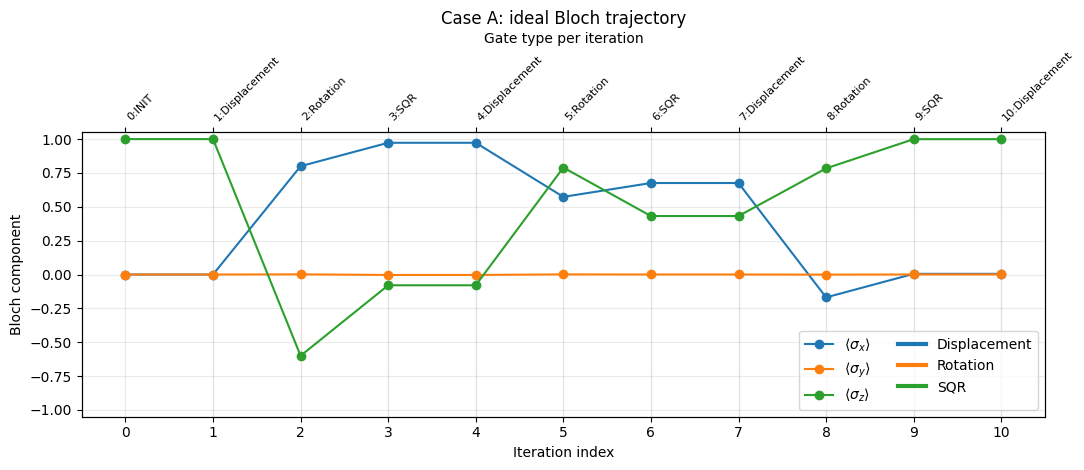

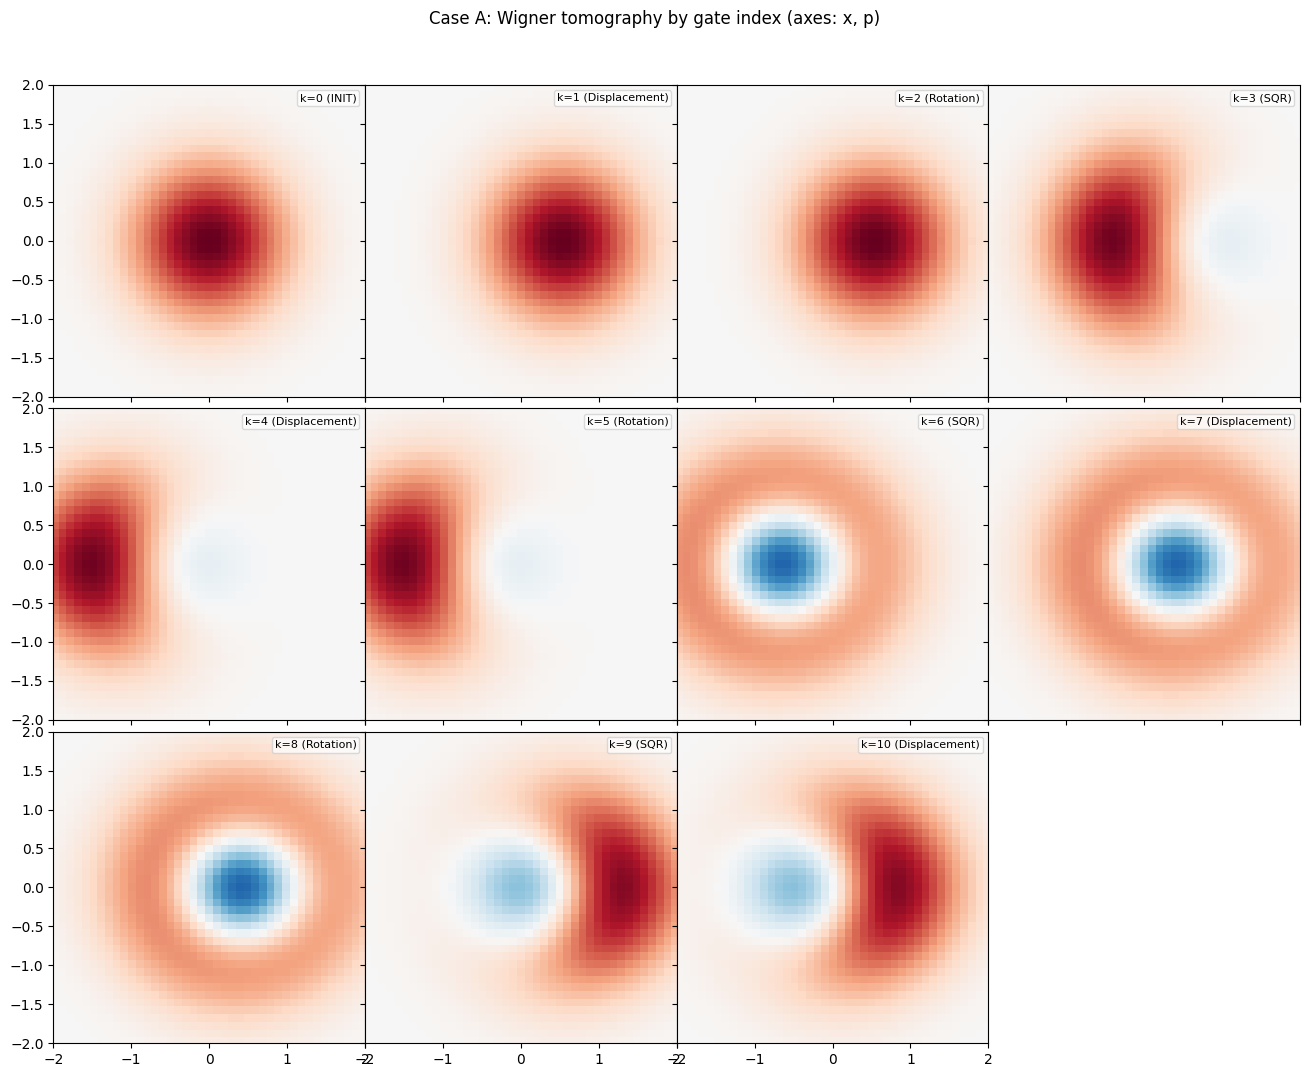

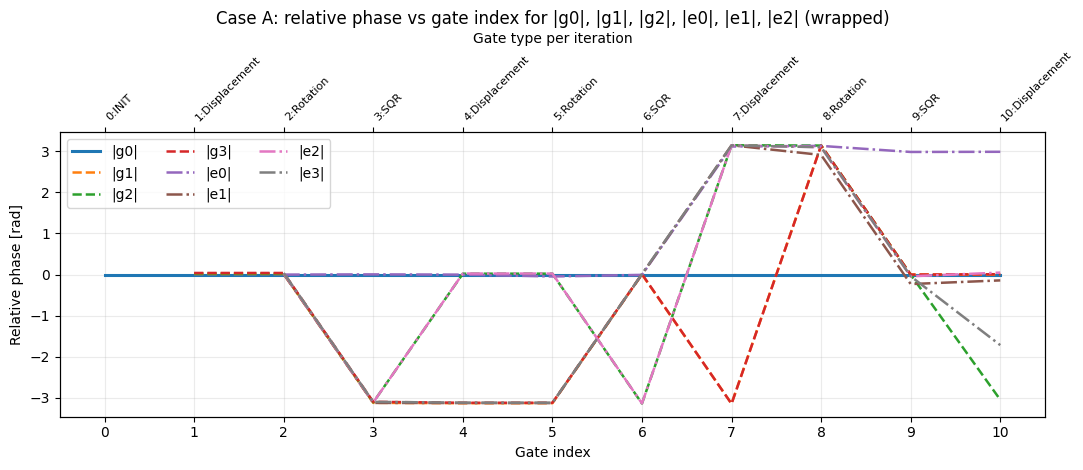

In [7]:
CASE_A = run_case_a(GATES, CONFIG)

print("Case A diagnostics:")
print({"solver": CASE_A["metadata"]["solver"], "final_x": CASE_A["x"][-1], "final_y": CASE_A["y"][-1], "final_z": CASE_A["z"][-1], "final_n": CASE_A["n"][-1]})

plot_bloch_track(CASE_A, title="Case A: ideal Bloch trajectory", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_A, title="Case A: Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]))
plt.show()

plot_relative_phase_track(
    CASE_A,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
)
plt.show()


## Section 6: Case B --- Pulse-level Simulation (No Dissipation)

SQR note:

`cqed_sim` provides dispersive manifold-frequency helpers, but not a notebook-ready Gaussian conditional-rotation builder. This section therefore uses a simplified multitone Gaussian RWA model:

- one Gaussian-windowed tone per active Fock manifold,
- tone frequencies from `cqed_sim.snap_opt.model.manifold_transition_frequency(...)`,
- per-tone area calibration `theta_n ≈ 2 * ∫ Ω_n(t) dt`.


Case B diagnostics:
{'solver': 'sesolve', 'final_x': -0.7401609584505687, 'final_y': -0.567592646609592, 'final_z': 0.2769836835148276, 'final_n': 0.5186464627518249}
Case B gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 3 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 6 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 7 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i *

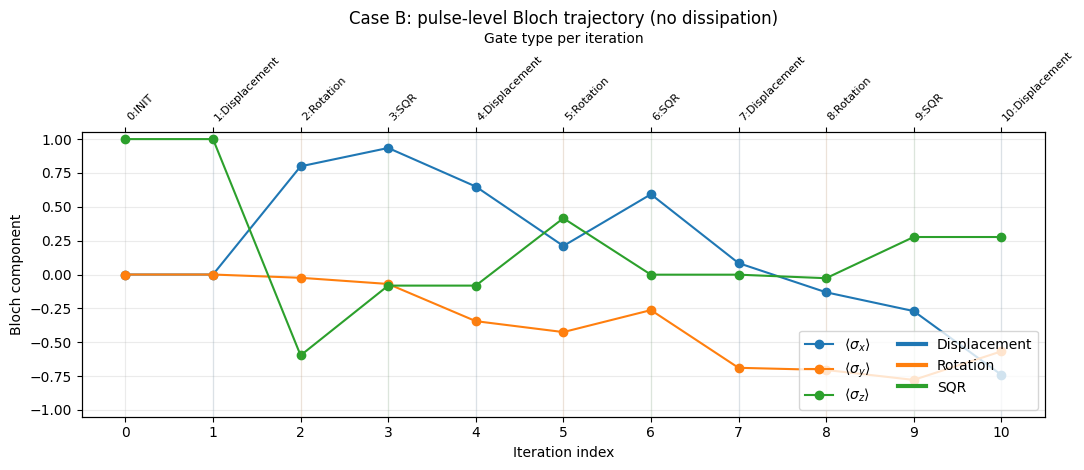

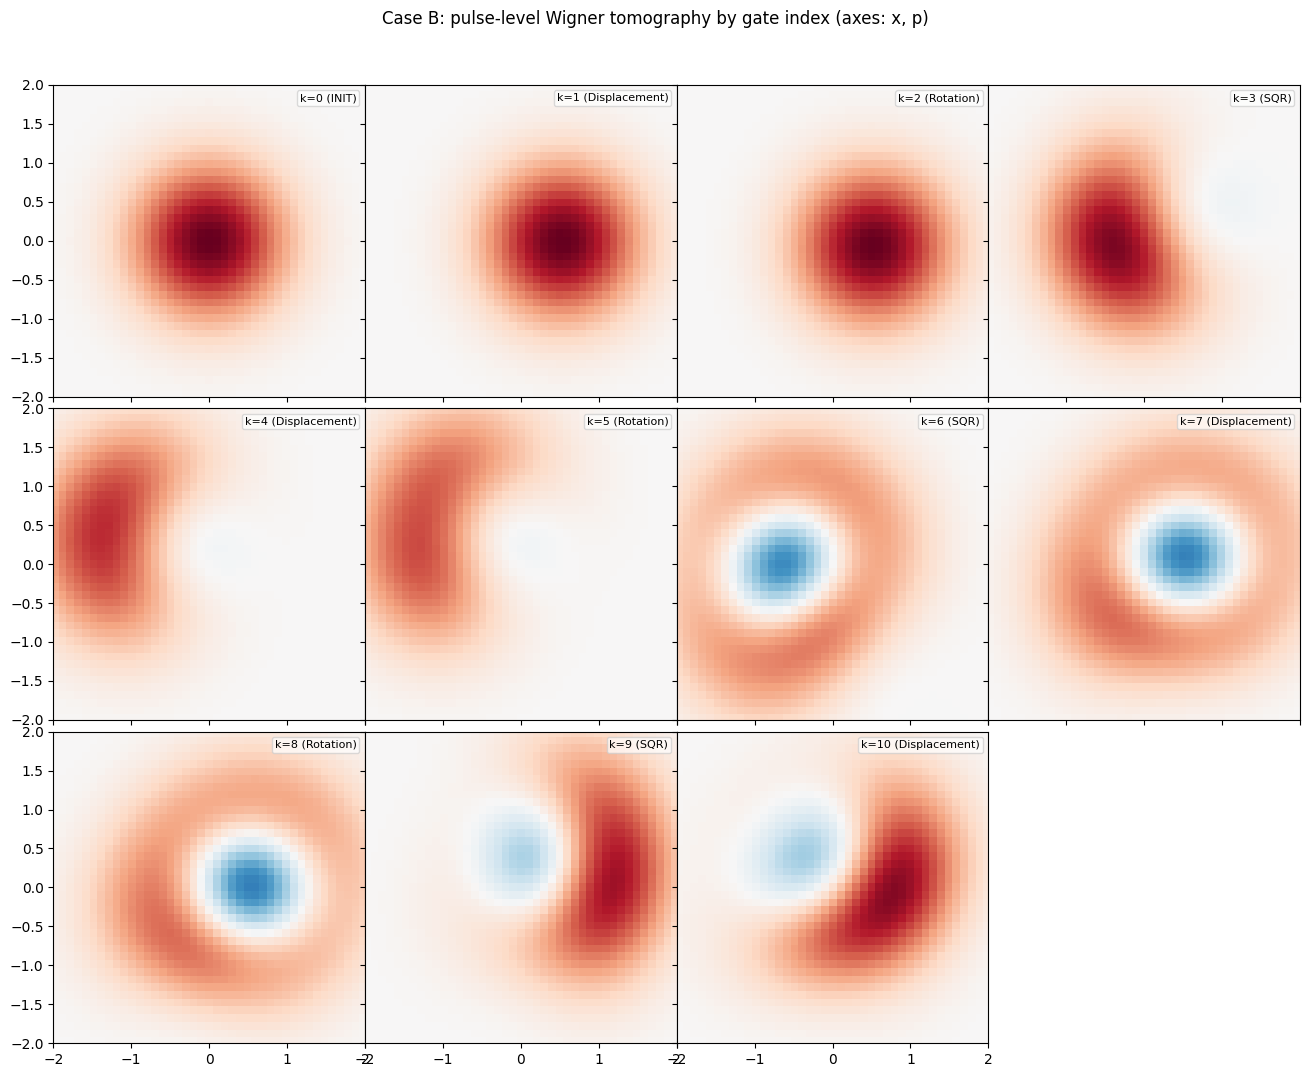

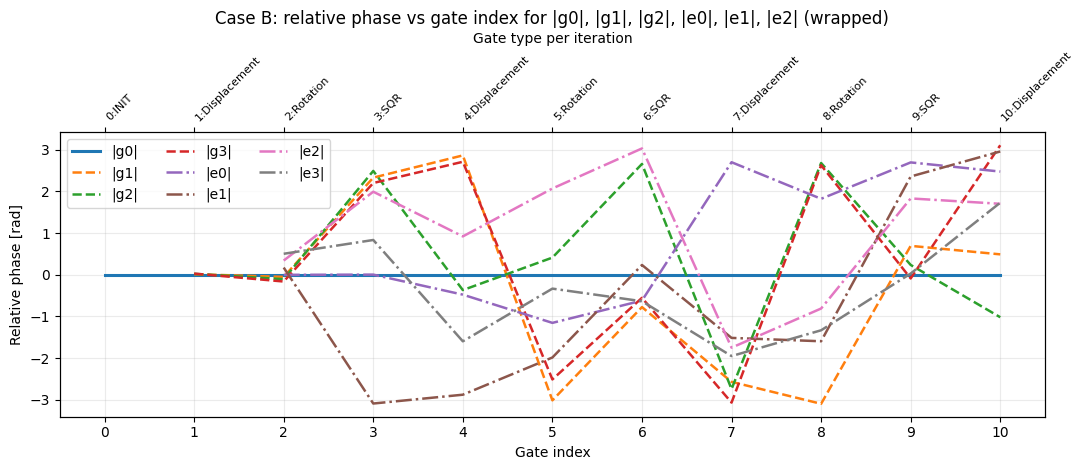

In [8]:
CASE_B = run_pulse_case(GATES, CONFIG, include_dissipation=False, case_label="Case B")

print("Case B diagnostics:")
print({"solver": CASE_B["metadata"]["solver"], "final_x": CASE_B["x"][-1], "final_y": CASE_B["y"][-1], "final_z": CASE_B["z"][-1], "final_n": CASE_B["n"][-1]})
print("Case B gate-to-pulse mapping:")
print_mapping_rows(CASE_B)

plot_bloch_track(CASE_B, title="Case B: pulse-level Bloch trajectory (no dissipation)", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_B, title="Case B: pulse-level Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]))
plt.show()

plot_relative_phase_track(
    CASE_B,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
)
plt.show()


## Section 7: Case C --- Pulse-level Simulation (With Dissipation)


Case C diagnostics:
{'solver': 'mesolve', 'final_x': -0.7127469803684212, 'final_y': -0.5356717786236507, 'final_z': 0.27956498636619004, 'final_n': 0.5270392604717896}
{'t1_s': 9.812087384824512e-05, 'tphi_s': 9.331110334423099e-05, 'kappa_1_per_s': None, 'gamma1_1_per_s': 10191.51135513338, 'gamma_phi_prefactor_1_per_s': 5358.419117127638}
Case C gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 3 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 6 SQR          Simplified multitone Gaussian SQR

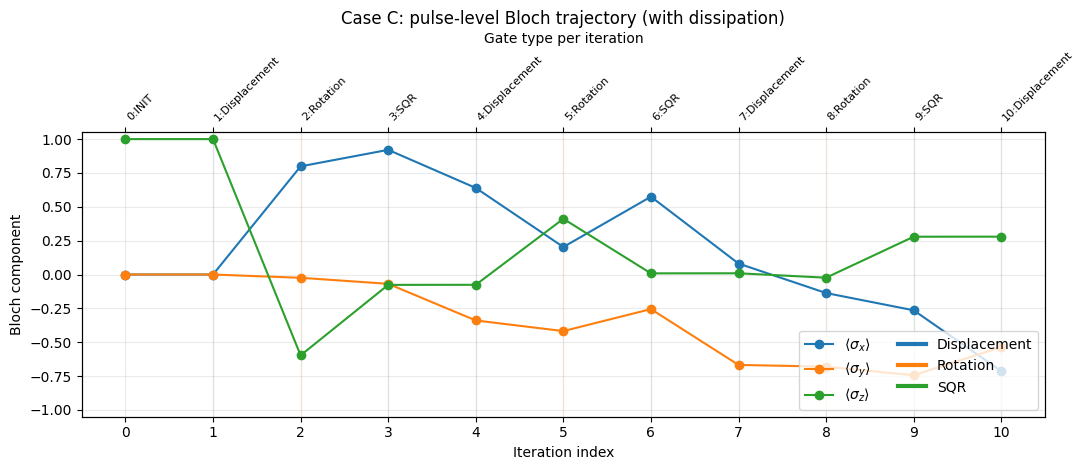

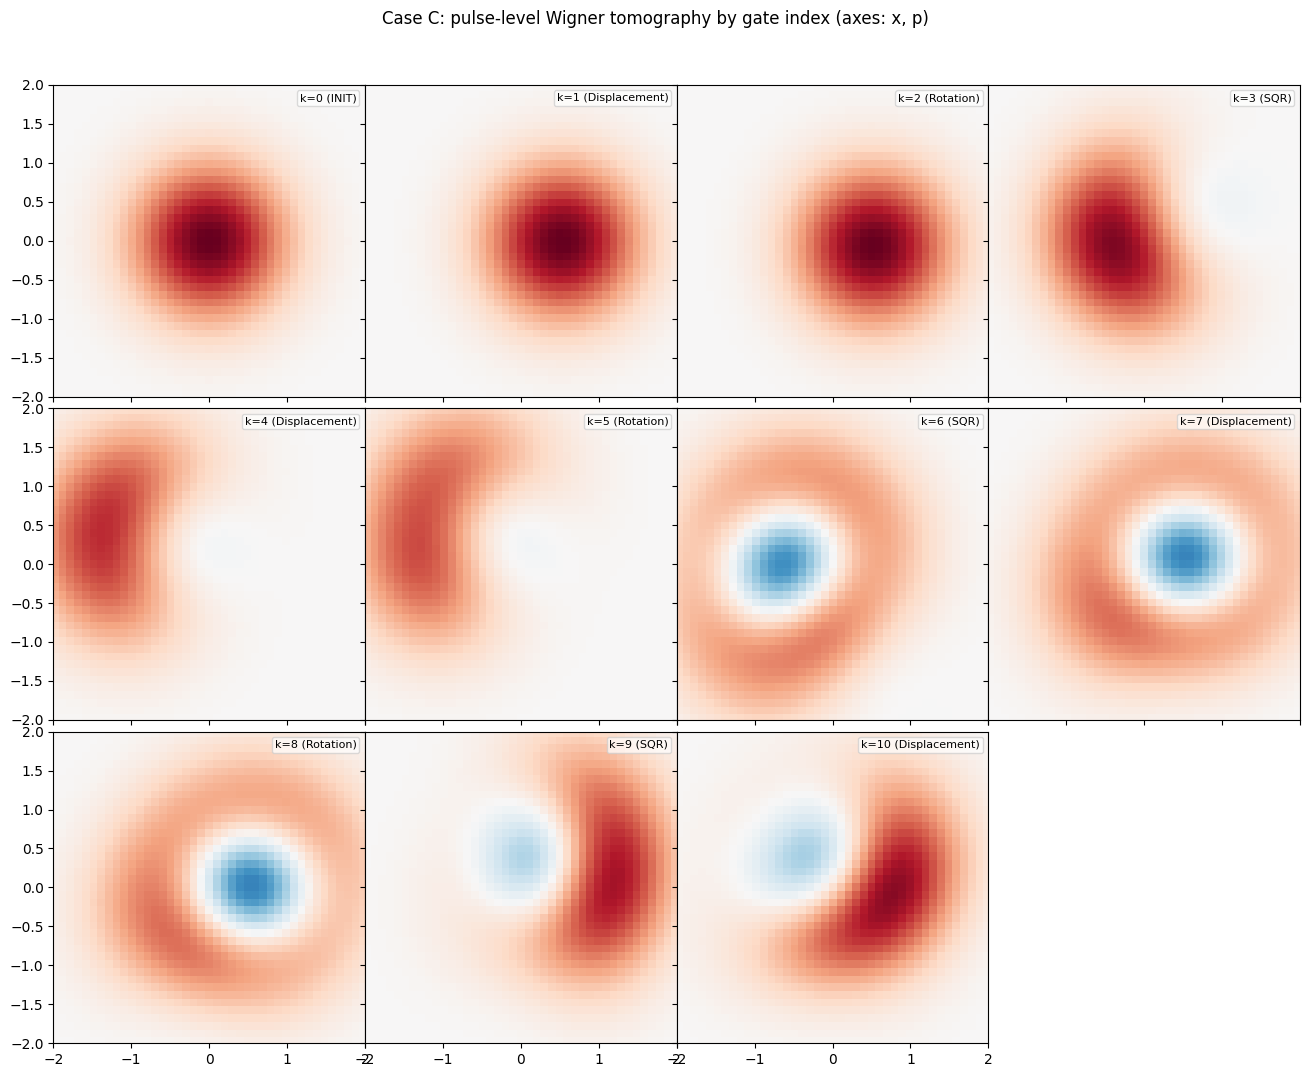

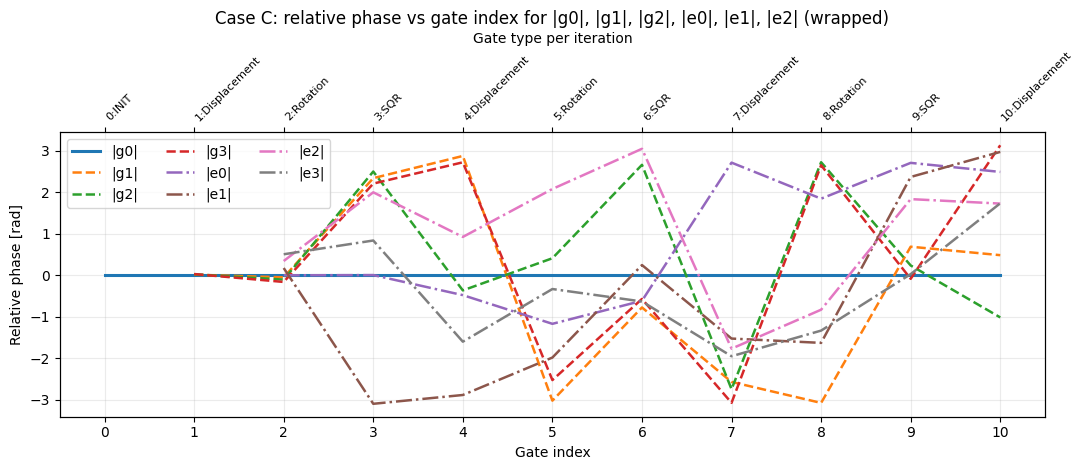

In [9]:
CASE_C = run_pulse_case(GATES, CONFIG, include_dissipation=True, case_label="Case C")

print("Case C diagnostics:")
print({"solver": CASE_C["metadata"]["solver"], "final_x": CASE_C["x"][-1], "final_y": CASE_C["y"][-1], "final_z": CASE_C["z"][-1], "final_n": CASE_C["n"][-1]})
noise = CASE_C["metadata"]["noise"]
print({"t1_s": None if noise is None else noise.t1, "tphi_s": None if noise is None else noise.tphi, "kappa_1_per_s": None if noise is None else noise.kappa, "gamma1_1_per_s": None if noise is None else noise.gamma1, "gamma_phi_prefactor_1_per_s": None if noise is None else noise.gamma_phi})
print("Case C gate-to-pulse mapping:")
print_mapping_rows(CASE_C)

plot_bloch_track(CASE_C, title="Case C: pulse-level Bloch trajectory (with dissipation)", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_C, title="Case C: pulse-level Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]))
plt.show()

plot_relative_phase_track(
    CASE_C,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
)
plt.show()


## Section 8: Weakness Metrics and Comparison Plots

Definitions used here:

- **Wigner negativity**: `0.5 * (integral |W| dx dp - 1)`.
- **Fidelity-based weakness**: `1 - F(rho_case, rho_A)` referenced to Case A at the same gate index.


e:\Program Files\Python311\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
e:\Program Files\Python311\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is ill-conditioned. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


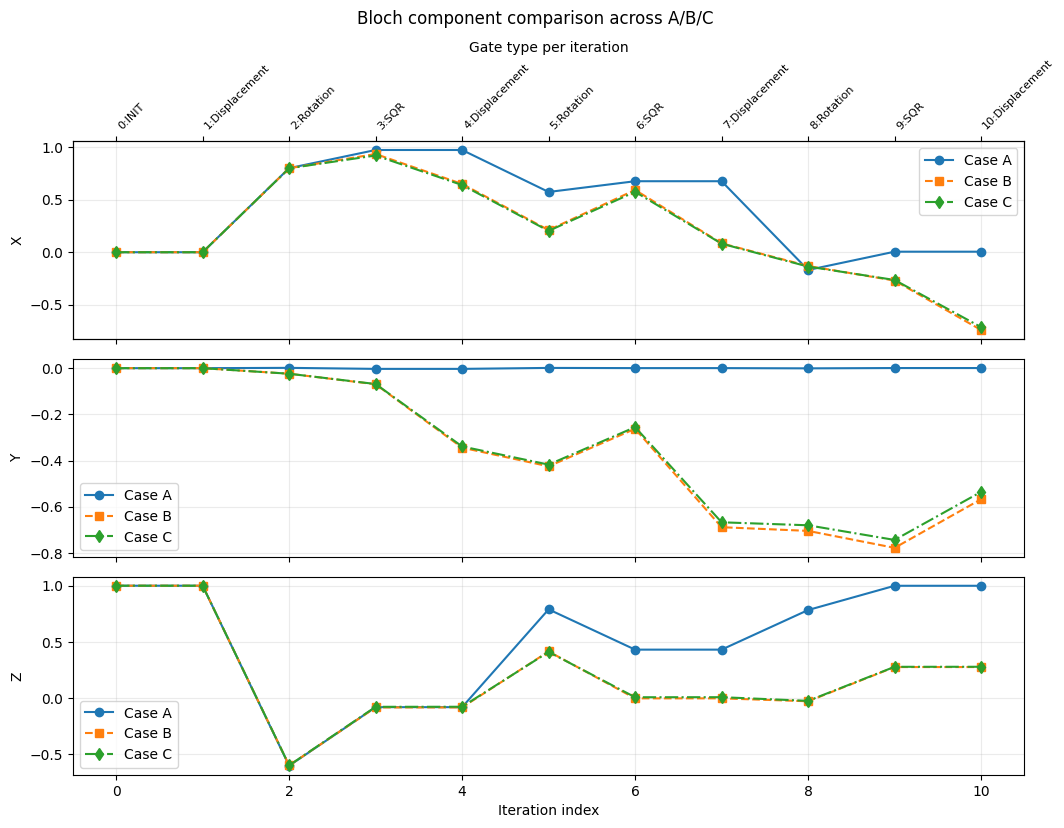

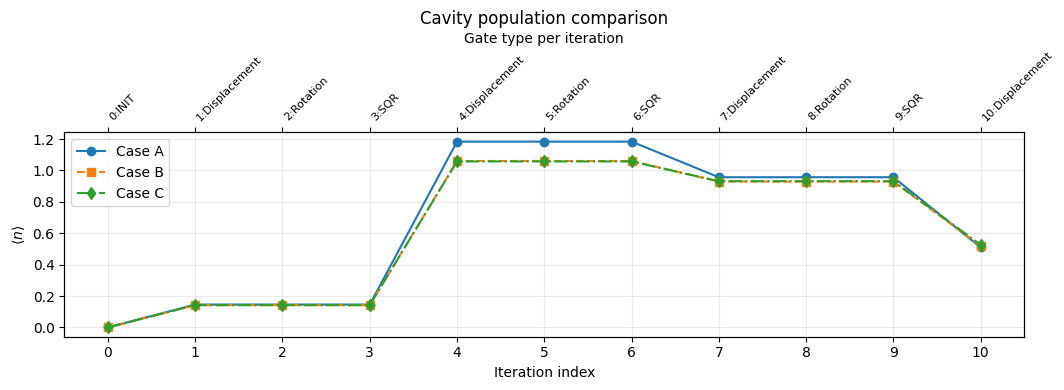

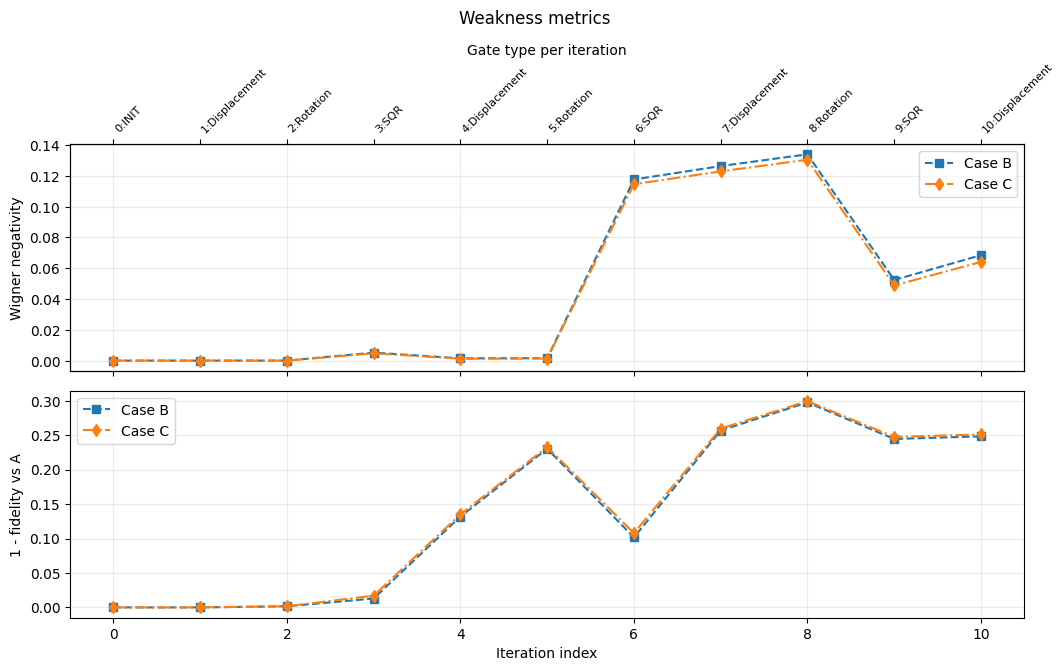

A vs B: {'x_rmse': 0.3338886437670658, 'y_rmse': 0.4544275024793819, 'z_rmse': 0.44893095000163946, 'n_rmse': 0.06617145056921526, 'final_fidelity': 0.7517605562279666}
A vs C: {'x_rmse': 0.33078300995922305, 'y_rmse': 0.4377467863587026, 'z_rmse': 0.4461937731620311, 'n_rmse': 0.06745792685401324, 'final_fidelity': 0.7490308518274795}


e:\Program Files\Python311\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is ill-conditioned. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [10]:
CASE_A = attach_weakness_metrics(CASE_A, CASE_A)
CASE_B = attach_weakness_metrics(CASE_A, CASE_B)
CASE_C = attach_weakness_metrics(CASE_A, CASE_C)

def plot_component_comparison(case_a: dict, case_b: dict, case_c: dict):
    fig, axes = plt.subplots(3, 1, figsize=(10.8, 8.4), sharex=True)
    for axis, key, label in zip(axes, ("x", "y", "z"), ("X", "Y", "Z")):
        axis.plot(case_a["indices"], case_a[key], "o-", label="Case A")
        axis.plot(case_b["indices"], case_b[key], "s--", label="Case B")
        axis.plot(case_c["indices"], case_c[key], "d-.", label="Case C")
        axis.set_ylabel(label)
        axis.grid(alpha=0.25)
        axis.legend(loc="best")
    axes[-1].set_xlabel("Iteration index")
    add_gate_type_axis(axes[0], case_a, label_stride=int(CONFIG["top_axis_label_stride"]), xlabel="Gate type per iteration")
    fig.suptitle("Bloch component comparison across A/B/C")
    fig.tight_layout()
    return fig


def plot_weakness(case_b: dict, case_c: dict):
    fig, axes = plt.subplots(2, 1, figsize=(10.8, 6.8), sharex=True)
    axes[0].plot(case_b["indices"], case_b["wigner_negativity"], "s--", label="Case B")
    axes[0].plot(case_c["indices"], case_c["wigner_negativity"], "d-.", label="Case C")
    axes[0].set_ylabel("Wigner negativity")
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="best")
    axes[1].plot(case_b["indices"], case_b["fidelity_weakness_vs_a"], "s--", label="Case B")
    axes[1].plot(case_c["indices"], case_c["fidelity_weakness_vs_a"], "d-.", label="Case C")
    axes[1].set_ylabel("1 - fidelity vs A")
    axes[1].set_xlabel("Iteration index")
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="best")
    add_gate_type_axis(axes[0], CASE_A, label_stride=int(CONFIG["top_axis_label_stride"]), xlabel="Gate type per iteration")
    fig.suptitle("Weakness metrics")
    fig.tight_layout()
    return fig


plot_component_comparison(CASE_A, CASE_B, CASE_C)
plt.show()

fig, ax = plt.subplots(figsize=(10.8, 4.0))
ax.plot(CASE_A["indices"], CASE_A["n"], "o-", label="Case A")
ax.plot(CASE_B["indices"], CASE_B["n"], "s--", label="Case B")
ax.plot(CASE_C["indices"], CASE_C["n"], "d-.", label="Case C")
ax.set_xlabel("Iteration index")
ax.set_ylabel(r"$\langle n \rangle$")
ax.set_title("Cavity population comparison")
ax.set_xticks(CASE_A["indices"])
ax.grid(alpha=0.25)
ax.legend(loc="best")
add_gate_type_axis(ax, CASE_A, label_stride=int(CONFIG["top_axis_label_stride"]), xlabel="Gate type per iteration")
fig.tight_layout()
plt.show()

plot_weakness(CASE_B, CASE_C)
plt.show()

COMPARISON_AB = comparison_metrics(CASE_A, CASE_B)
COMPARISON_AC = comparison_metrics(CASE_A, CASE_C)
print("A vs B:", COMPARISON_AB)
print("A vs C:", COMPARISON_AC)


## Section 9: Test Suite


In [11]:
def assert_close(actual, expected, atol: float, label: str):
    if not np.allclose(actual, expected, atol=atol, rtol=0.0):
        raise AssertionError(f"{label} mismatch. expected={expected}, actual={actual}")


def test_1_ideal_rotation_sanity():
    cfg = copy.deepcopy(CONFIG)
    cfg["cavity_fock_cutoff"] = 0
    cfg["n_cav_dim"] = 1
    gate = {"index": 0, "type": "Rotation", "target": "qubit", "name": "x90", "params": {"theta": np.pi / 2.0, "phi": 0.0}}
    out = ideal_gate_unitary(gate, 1) * build_initial_state(cfg, n_cav_dim=1)
    assert_close(np.asarray(bloch_xyz_from_joint(out)), np.array([0.0, -1.0, 0.0]), atol=2e-3, label="Test 1")
    if not np.isclose(purity(out), 1.0, atol=1e-10):
        raise AssertionError("Test 1 purity was not preserved.")


def test_2_case_b_displacement_sanity():
    cfg = copy.deepcopy(CONFIG)
    cfg.update({"cavity_fock_cutoff": 18, "n_cav_dim": 19, "omega_c_hz": 0.0, "st_chi_hz": 0.0, "st_chi2_hz": 0.0, "st_chi3_hz": 0.0, "st_K_hz": 0.0, "st_K2_hz": 0.0})
    gate = {"index": 0, "type": "Displacement", "target": "storage", "name": "disp", "params": {"re": 0.25, "im": -0.15}}
    track = run_pulse_case([gate], cfg, include_dissipation=False, case_label="Case B test")
    a = qt.destroy(int(cfg["n_cav_dim"]))
    if not np.isclose(qt.expect(a, track["snapshots"][-1]["rho_c"]), complex(gate["params"]["re"], gate["params"]["im"]), atol=5e-2):
        raise AssertionError("Test 2 pulse-level displacement missed target alpha.")


def test_3_sqr_conditionality():
    gate = {"index": 0, "type": "SQR", "target": "qubit", "name": "sqr", "params": {"theta": [0.0, np.pi / 2.0], "phi": [0.0, np.pi / 2.0]}}
    psi = qt.tensor((qt.basis(4, 0) + qt.basis(4, 1)).unit(), qt.basis(2, 0))
    out = ideal_gate_unitary(gate, 4) * psi
    if not purity(reduced_qubit_state(out)) < 0.999:
        raise AssertionError("Test 3 expected qubit mixedness after conditional rotation.")


def test_4_decoherence_limits():
    model = DispersiveTransmonCavityModel(omega_c=0.0, omega_q=0.0, alpha=0.0, chi=0.0, kerr=0.0, n_cav=2, n_tr=2)
    compiled = SequenceCompiler(dt=0.02).compile([], t_end=1.0)
    res_t1 = simulate_sequence(model, compiled, model.basis_state(0, 1), {}, SimulationConfig(), noise=NoiseSpec(t1=1.0))
    if not np.isclose(bloch_xyz_from_joint(res_t1.final_state)[2], 1.0 - 2.0 * math.e ** (-1.0), atol=0.06):
        raise AssertionError("Test 4 T1 decay mismatch.")
    plus = qt.tensor(qt.basis(2, 0), (qt.basis(2, 0) + qt.basis(2, 1)).unit())
    res_tphi = simulate_sequence(model, compiled, plus, {}, SimulationConfig(), noise=NoiseSpec(tphi=1.0))
    if not np.isclose(bloch_xyz_from_joint(res_tphi.final_state)[0], math.e ** (-1.0), atol=0.06):
        raise AssertionError("Test 4 Tphi decay mismatch.")


def test_5_case_a_vs_case_b_ideal_limit():
    gates = [
        {"index": 0, "type": "Rotation", "target": "qubit", "name": "x90", "params": {"theta": np.pi / 2.0, "phi": 0.0}},
        {"index": 1, "type": "Displacement", "target": "storage", "name": "disp", "params": {"re": 0.2, "im": -0.1}},
    ]
    cfg = copy.deepcopy(CONFIG)
    cfg.update({"cavity_fock_cutoff": 12, "n_cav_dim": 13, "omega_c_hz": 0.0, "omega_q_hz": 0.0, "qubit_alpha_hz": 0.0, "st_chi_hz": 0.0, "st_chi2_hz": 0.0, "st_chi3_hz": 0.0, "st_K_hz": 0.0, "st_K2_hz": 0.0, "duration_displacement_s": 1.0, "duration_rotation_s": 1.0, "dt_s": 2.5e-4, "max_step_s": 2.5e-4})
    case_a = run_case_a(gates, cfg)
    case_b = run_pulse_case(gates, cfg, include_dissipation=False, case_label="Case B test")
    metrics = comparison_metrics(case_a, case_b)
    for key in ("x_rmse", "y_rmse", "z_rmse", "n_rmse"):
        if not metrics[key] < 4e-2:
            raise AssertionError(f"Test 5 {key} too large: {metrics[key]}")


NOTEBOOK_TESTS = [
    ("Test 1: ideal rotation sanity", test_1_ideal_rotation_sanity),
    ("Test 2: Case B displacement sanity", test_2_case_b_displacement_sanity),
    ("Test 3: SQR conditionality", test_3_sqr_conditionality),
    ("Test 4: decoherence limits", test_4_decoherence_limits),
    ("Test 5: Case A vs Case B ideal limit", test_5_case_a_vs_case_b_ideal_limit),
]

TEST_RESULTS = []
for label, fn in NOTEBOOK_TESTS:
    fn()
    TEST_RESULTS.append({"label": label, "status": "PASS"})
    print(f"PASS: {label}")

TEST_RESULTS


PASS: Test 1: ideal rotation sanity
PASS: Test 2: Case B displacement sanity
PASS: Test 3: SQR conditionality
PASS: Test 4: decoherence limits
PASS: Test 5: Case A vs Case B ideal limit


[{'label': 'Test 1: ideal rotation sanity', 'status': 'PASS'},
 {'label': 'Test 2: Case B displacement sanity', 'status': 'PASS'},
 {'label': 'Test 3: SQR conditionality', 'status': 'PASS'},
 {'label': 'Test 4: decoherence limits', 'status': 'PASS'},
 {'label': 'Test 5: Case A vs Case B ideal limit', 'status': 'PASS'}]

## Section 10: Final Summary Tables and Notes


In [12]:
def final_case_summary(track: dict) -> dict:
    final = track["snapshots"][-1]
    return {
        "case": track["case"],
        "solver": track["metadata"]["solver"],
        "final_x": final["x"],
        "final_y": final["y"],
        "final_z": final["z"],
        "final_n": final["n"],
        "final_qubit_purity": final["qubit_purity"],
        "final_cavity_purity": final["cavity_purity"],
        "final_wigner_negativity": float(track["wigner_negativity"][-1]),
        "final_fidelity_weakness_vs_a": float(track["fidelity_weakness_vs_a"][-1]),
    }


FINAL_SUMMARIES = [final_case_summary(track) for track in (CASE_A, CASE_B, CASE_C)]
print("Final case summaries:")
for row in FINAL_SUMMARIES:
    print(row)

print("\nNotes:")
print("- Case A is the instantaneous-unitary baseline.")
print("- Case B and Case C use the same pulse shapes; Case C adds Lindblad dissipation.")
print("- SQR in Cases B/C uses a simplified multitone Gaussian selective-drive approximation tied to cqed_sim dispersive manifold frequencies.")
print("- Bloch plots intentionally keep gate-type labels only on the top x-axis to avoid duplication.")


Final case summaries:
{'case': 'Case A', 'solver': 'instantaneous_unitary', 'final_x': 0.005061829077818567, 'final_y': 0.0005559005790004141, 'final_z': 0.9995098045492457, 'final_n': 0.5095751996537795, 'final_qubit_purity': 0.9995228902645685, 'final_cavity_purity': 0.9995228902645689, 'final_wigner_negativity': 0.08238067367609514, 'final_fidelity_weakness_vs_a': -1.5827203769802622e-08}
{'case': 'Case B', 'solver': 'sesolve', 'final_x': -0.7401609584505687, 'final_y': -0.567592646609592, 'final_z': 0.2769836835148276, 'final_n': 0.5186464627518249, 'final_qubit_purity': 0.9733598089165942, 'final_cavity_purity': 0.9733598089165941, 'final_wigner_negativity': 0.06847624094911675, 'final_fidelity_weakness_vs_a': 0.24823944377203344}
{'case': 'Case C', 'solver': 'mesolve', 'final_x': -0.7127469803684212, 'final_y': -0.5356717786236507, 'final_z': 0.27956498636619004, 'final_n': 0.5270392604717896, 'final_qubit_purity': 0.9365545470200285, 'final_cavity_purity': 0.948433182742319, 'fi